In [5]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/iot/pad_ufes_20
%ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/iot/pad_ufes_20
images/  metadata.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns
import io
from scipy.stats import zscore

pd.set_option('display.max_columns', None)

In [ ]:
pad_dataset = pd.read_csv('metadata.csv')
pad_dataset.head()


,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,has_sewage_system,fitspatrick,region,diameter_1,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ARM,NaN,NaN,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,True,True,True,3.0,NECK,6.0,5.0,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FACE,NaN,NaN,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HAND,NaN,NaN,ACK,True,False,False,False,False,False,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,False,False,False,1.0,FOREARM,5.0,5.0,BCC,True,True,False,False,True,True,PAT_684_1302_588.png,True


In [51]:
pad_dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
lesion_id,2298.0,1529.933856,1196.285644,6.0,720.5,1297.0,1782.75,4820.0
age,2298.0,60.464752,15.894866,6.0,52.0,62.0,72.00,94.0
fitspatrick,1494.0,2.265730,0.729029,1.0,2.0,2.0,3.00,6.0
diameter_1,1494.0,11.897055,8.634492,0.0,7.0,10.0,15.00,100.0
diameter_2,1494.0,8.852209,5.797036,0.0,5.0,8.0,10.00,70.0


In [ ]:
# msh ai sare2ha mn stackoverflow
buffer = io.StringIO()
pad_dataset.info(buf=buffer)
lines = buffer.getvalue().splitlines()
pad_dataset_info = (pd.DataFrame([x.split() for x in lines[5:-2]], columns=lines[3].split())
       .drop(['Count', '#'],axis=1)
       .rename(columns={'Non-Null':'Non-Null Count'}))

pad_dataset_info   

,Column,Non-Null Count,Dtype
0,patient_id,2298,object
1,lesion_id,2298,int64
2,smoke,1494,object
3,drink,1494,object
4,background_father,1480,object
5,background_mother,1476,object
6,age,2298,int64
7,pesticide,1494,object
8,gender,1494,object
9,skin_cancer_history,1494,object


,background_mother,background_father,smoke,drink,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,has_sewage_system,fitspatrick,diameter_1,diameter_2
Null Percentage,35.77,35.6,34.99,34.99,34.99,34.99,34.99,34.99,34.99,34.99,34.99,34.99,34.99


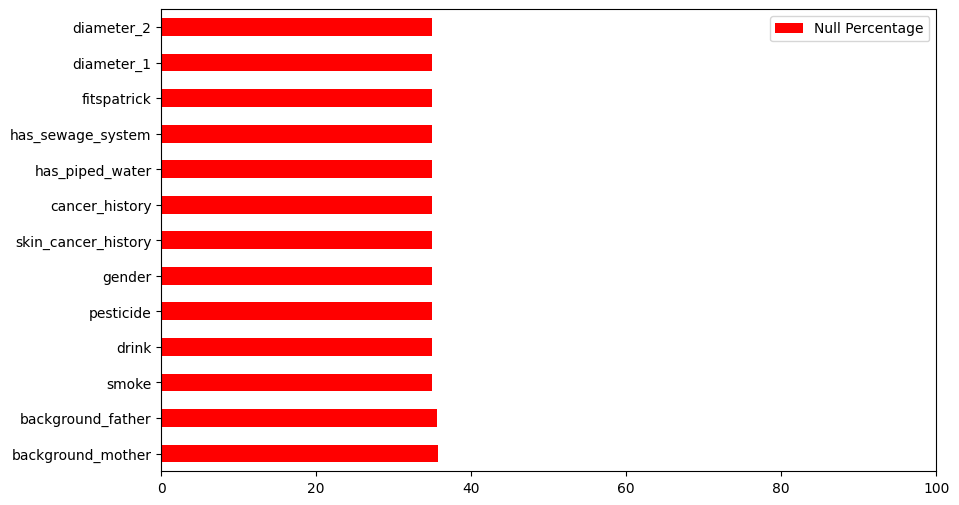

In [80]:
# 1. Calculate and filter
null_perc = (pad_dataset.isnull().mean() * 100).round(2)
null_perc_filtered = null_perc[null_perc > 0]

null_perc = (null_perc_filtered
            .to_frame(name='Null Percentage')
            .sort_values(by='Null Percentage', ascending=False))

null_perc.plot(kind='barh', figsize=(10, 6), xlim=(0, 100), color='red')
null_perc.T

## Feature Dictionary

This dataset contains **patient-level and lesion-level metadata** used for dermatology analysis.  
Each row represents a lesion record with demographic, clinical, symptom, and context information.

### 1) Identifier Features

| Feature | Type | Description | Notes |
|---|---|---|---|
| `patient_id` | object | Unique identifier for a patient. | Multiple lesions may belong to the same patient. |
| `lesion_id` | int64 | Unique identifier for a lesion. | Useful for lesion-level tracking. |
| `img_id` | object | Image file identifier/name associated with the lesion. | Links metadata to lesion image. |

---

### 2) Lifestyle / Exposure Features

| Feature | Type | Description | Notes |
|---|---|---|---|
| `smoke` | object (bool-like) | Indicates whether the patient smokes. | Contains missing values. |
| `drink` | object (bool-like) | Indicates alcohol consumption. | Contains missing values. |
| `pesticide` | object (bool-like) | Indicates pesticide exposure/history. | Contains missing values. |

---

### 3) Family / Background Features

| Feature | Type | Description | Notes |
|---|---|---|---|
| `background_father` | object | Paternal Country. | High missingness. |
| `background_mother` | object | Maternal Country. | High missingness. |

---

### 4) Demographic Features

| Feature | Type | Description | Notes |
|---|---|---|---|
| `age` | int64 | Patient age in years. | Fully populated in shown summary. |
| `gender` | object | Patient gender. | Contains missing values. |
| `region` | object | Body region where lesion is located (e.g., FACE, ARM). | Anatomical location feature. |

---

### 5) Medical History Features

| Feature | Type | Description | Notes |
|---|---|---|---|
| `skin_cancer_history` | object (bool-like) | Prior history of skin cancer. | Contains missing values. |
| `cancer_history` | object (bool-like) | Prior general cancer history. | Contains missing values. |

---

### 6) Infrastructure / Environment Features

| Feature | Type | Description | Notes |
|---|---|---|---|
| `has_piped_water` | object (bool-like) | Indicates household piped water access. | Contains missing values. |
| `has_sewage_system` | object (bool-like) | Indicates household sewage access. | Contains missing values. |

---

### 7) Skin / Lesion Physical Features

| Feature | Type | Description | Notes |
|---|---|---|---|
| `fitspatrick` | float64 | Fitzpatrick skin phototype (likely I–VI encoded numerically). | Contains missing values. |
| `diameter_1` | float64 | First lesion diameter measurement. | Likely in mm; contains missing values. |
| `diameter_2` | float64 | Second lesion diameter measurement. | Likely in mm; contains missing values. |

---

### 8) Clinical Label and Symptoms

| Feature | Type | Description | Notes |
|---|---|---|---|
| `diagnostic` | object | Diagnostic class/category of lesion (e.g., BCC, NEV, ACK, SEK). | Multi-class clinical label. |
| `itch` | object (bool-like) | Whether lesion is itchy. | Symptom indicator. |
| `grew` | object (bool-like) | Whether lesion has grown over time. | Symptom/progression indicator. |
| `hurt` | object (bool-like) | Whether lesion is painful. | Symptom indicator. |
| `changed` | object (bool-like) | Whether lesion has changed appearance. | Progression indicator. |
| `bleed` | object (bool-like) | Whether lesion bleeds. | Symptom severity cue. |
| `elevation` | object (bool-like) | Whether lesion is elevated/raised. | Morphological cue. |
| `biopsed` | bool | Whether lesion was biopsied. | Binary clinical action/outcome. |

---

## Quick Analysis 

- Several metadata features have substantial missingness (about **35%** in key columns such as `smoke`, `drink`, `gender`, `fitspatrick`, `diameter_1`, `diameter_2`, etc.).
- Many boolean-like columns are stored as `object`; consider converting to proper boolean/categorical types.
- `diagnostic` is typically the main disease-class label, while `biopsed` can be used as a separate binary target depending on task definition.
- `patient_id` should be considered during train/test splitting to avoid leakage across lesions from the same patient.

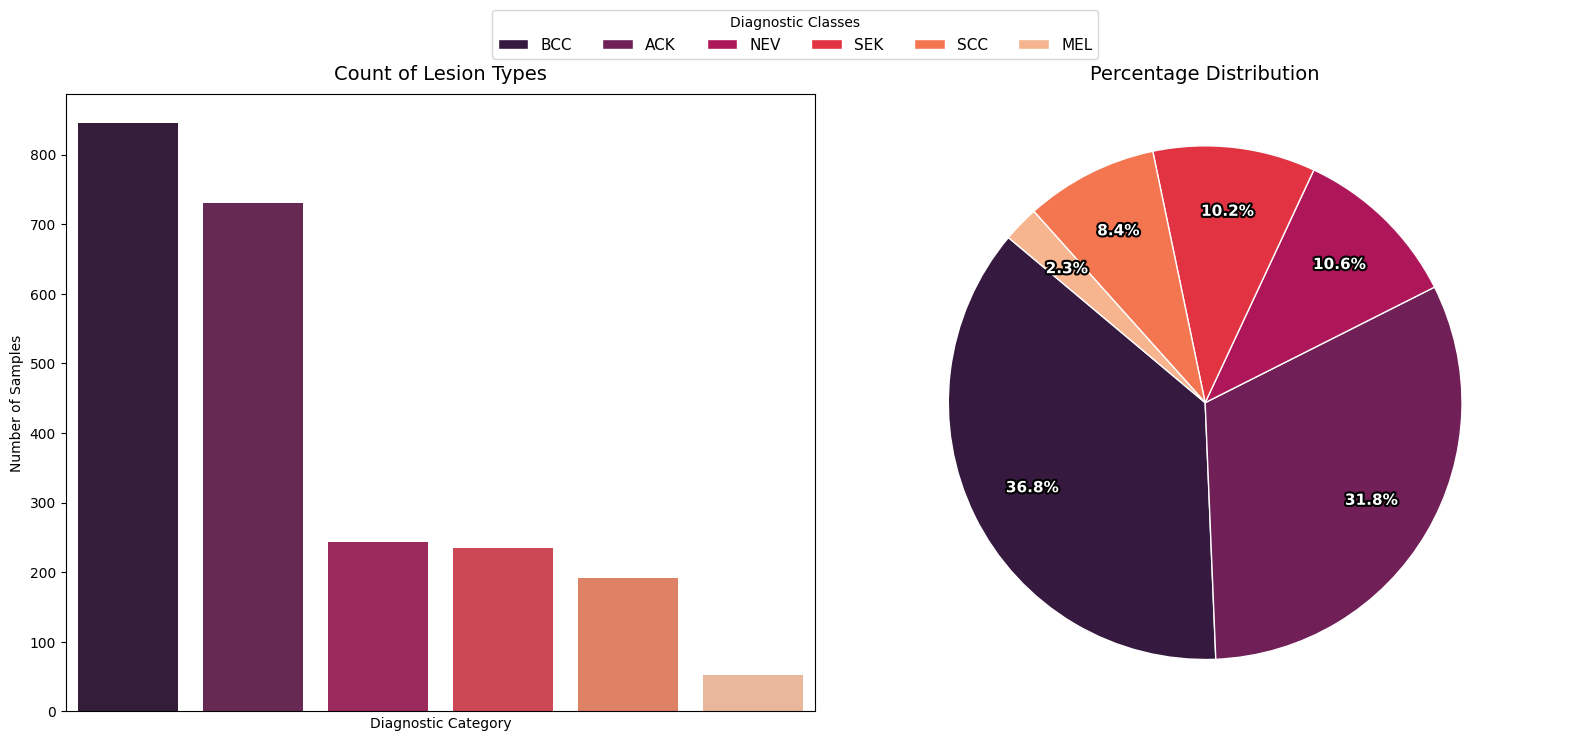

,count
diagnostic,
BCC,845
ACK,730
NEV,244
SEK,235
SCC,192
MEL,52


In [135]:
class_counts = pad_dataset['diagnostic'].value_counts()
colors = sns.color_palette('rocket', len(class_counts))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Bar Plot
sns.barplot(
    x=class_counts.index, 
    y=class_counts.values, 
    hue=class_counts.index, 
    palette=colors, 
    ax=ax1
)
ax1.set_title('Count of Lesion Types', fontsize=14, pad=10)
ax1.set_ylabel('Number of Samples')
ax1.set_xticks([]) 
ax1.set_xlabel('Diagnostic Category')

# Pie Chart
wedges, texts, autotexts = ax2.pie(
    class_counts, 
    labels=None, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1},
    pctdistance=0.75
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')
    autotext.set_fontsize(11)
    autotext.set_path_effects([path_effects.withStroke(linewidth=3, foreground='black')])

ax2.set_title('Percentage Distribution', fontsize=14, pad=10)
ax2.axis('equal') 

fig.legend(
    wedges, 
    class_counts.index, 
    title="Diagnostic Classes",
    loc="upper center", 
    bbox_to_anchor=(0.5, 0.98), # Centered horizontally at the very top
    ncol=len(class_counts),      # Horizontal row
    fontsize=11,
    frameon=True
)

plt.tight_layout(rect=[0, 0.05, 1, 0.92]) 
plt.show()

class_counts

### Handle nulls

In [167]:
null_columns = null_perc.T.columns
null_columns_info = pad_dataset_info[pad_dataset_info['Column'].isin(null_columns)]

null_columns_info

,Column,Non-Null Count,Dtype
2,smoke,1494,object
3,drink,1494,object
4,background_father,1480,object
5,background_mother,1476,object
7,pesticide,1494,object
8,gender,1494,object
9,skin_cancer_history,1494,object
10,cancer_history,1494,object
11,has_piped_water,1494,object
12,has_sewage_system,1494,object


In [186]:
cat_cols = null_columns_info[null_columns_info['Dtype'] == 'object']['Column'].tolist()
num_cols = null_columns_info[null_columns_info['Dtype'].astype(str).str.contains('float')]['Column'].tolist()

print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)

Categorical Columns: ['smoke', 'drink', 'background_father', 'background_mother', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system']
Numerical Columns: ['fitspatrick', 'diameter_1', 'diameter_2']


In [173]:
# handle categorical columns null values by adding a new category "Unknown"
clean_pad_dataset = pad_dataset.copy()
clean_pad_dataset[cat_cols] = clean_pad_dataset[cat_cols].fillna('Unknown')

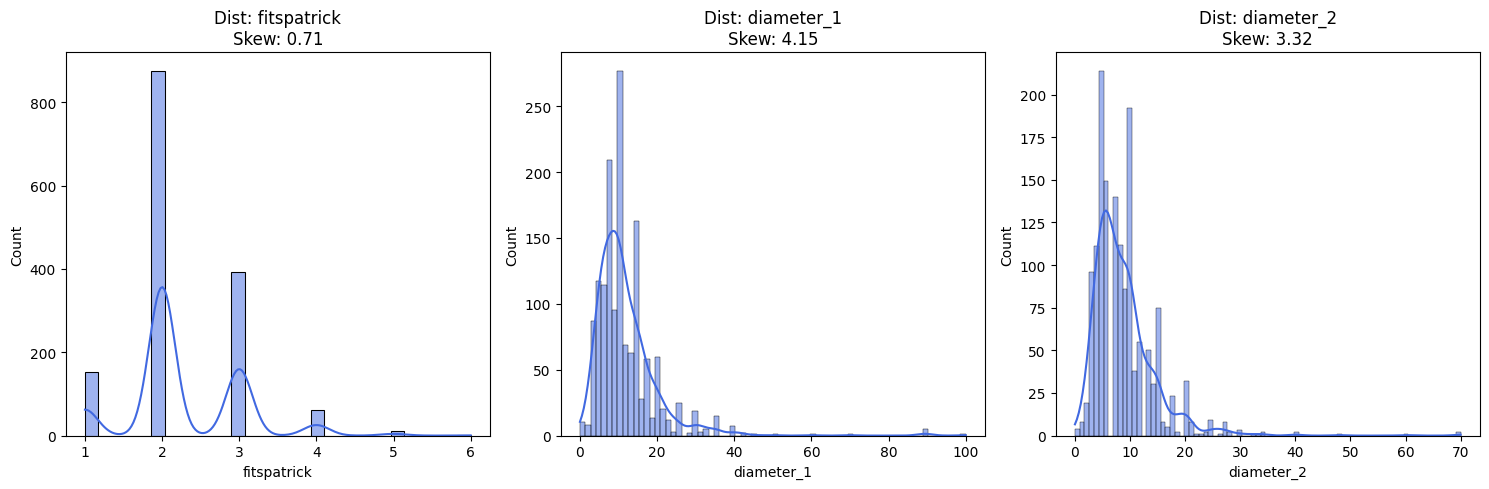

In [174]:
# handle numerical columns null values
fig, axes = plt.subplots(1, len(num_cols), figsize=(15, 5))
for i, col in enumerate(num_cols):
    sns.histplot(pad_dataset[col].dropna(), kde=True, ax=axes[i], color='royalblue')
    axes[i].set_title(f'Dist: {col}\nSkew: {pad_dataset[col].skew():.2f}')

plt.tight_layout()
plt.show()

In [ ]:
clean_pad_dataset[num_cols] = clean_pad_dataset[num_cols].fillna(clean_pad_dataset[num_cols].median())
clean_pad_dataset.isnull().sum().sum()

,0
patient_id,0
lesion_id,0
smoke,0
drink,0
background_father,0
background_mother,0
age,0
pesticide,0
gender,0
skin_cancer_history,0


### handle outliers

In [189]:
# exclude fitspatrick column
num_cols = [col for col in num_cols if col != 'fitspatrick']
num_cols

['diameter_1', 'diameter_2']

In [194]:
# Outlier detection with IQR and boxplots
Q1 = clean_pad_dataset[num_cols].quantile(0.25)
Q3 = clean_pad_dataset[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (clean_pad_dataset[num_cols] < lower_bound) | (clean_pad_dataset[num_cols] > upper_bound)
outlier_counts = outlier_mask.sum().sort_values(ascending=False)

outlier_counts

,0
diameter_1,359
diameter_2,232


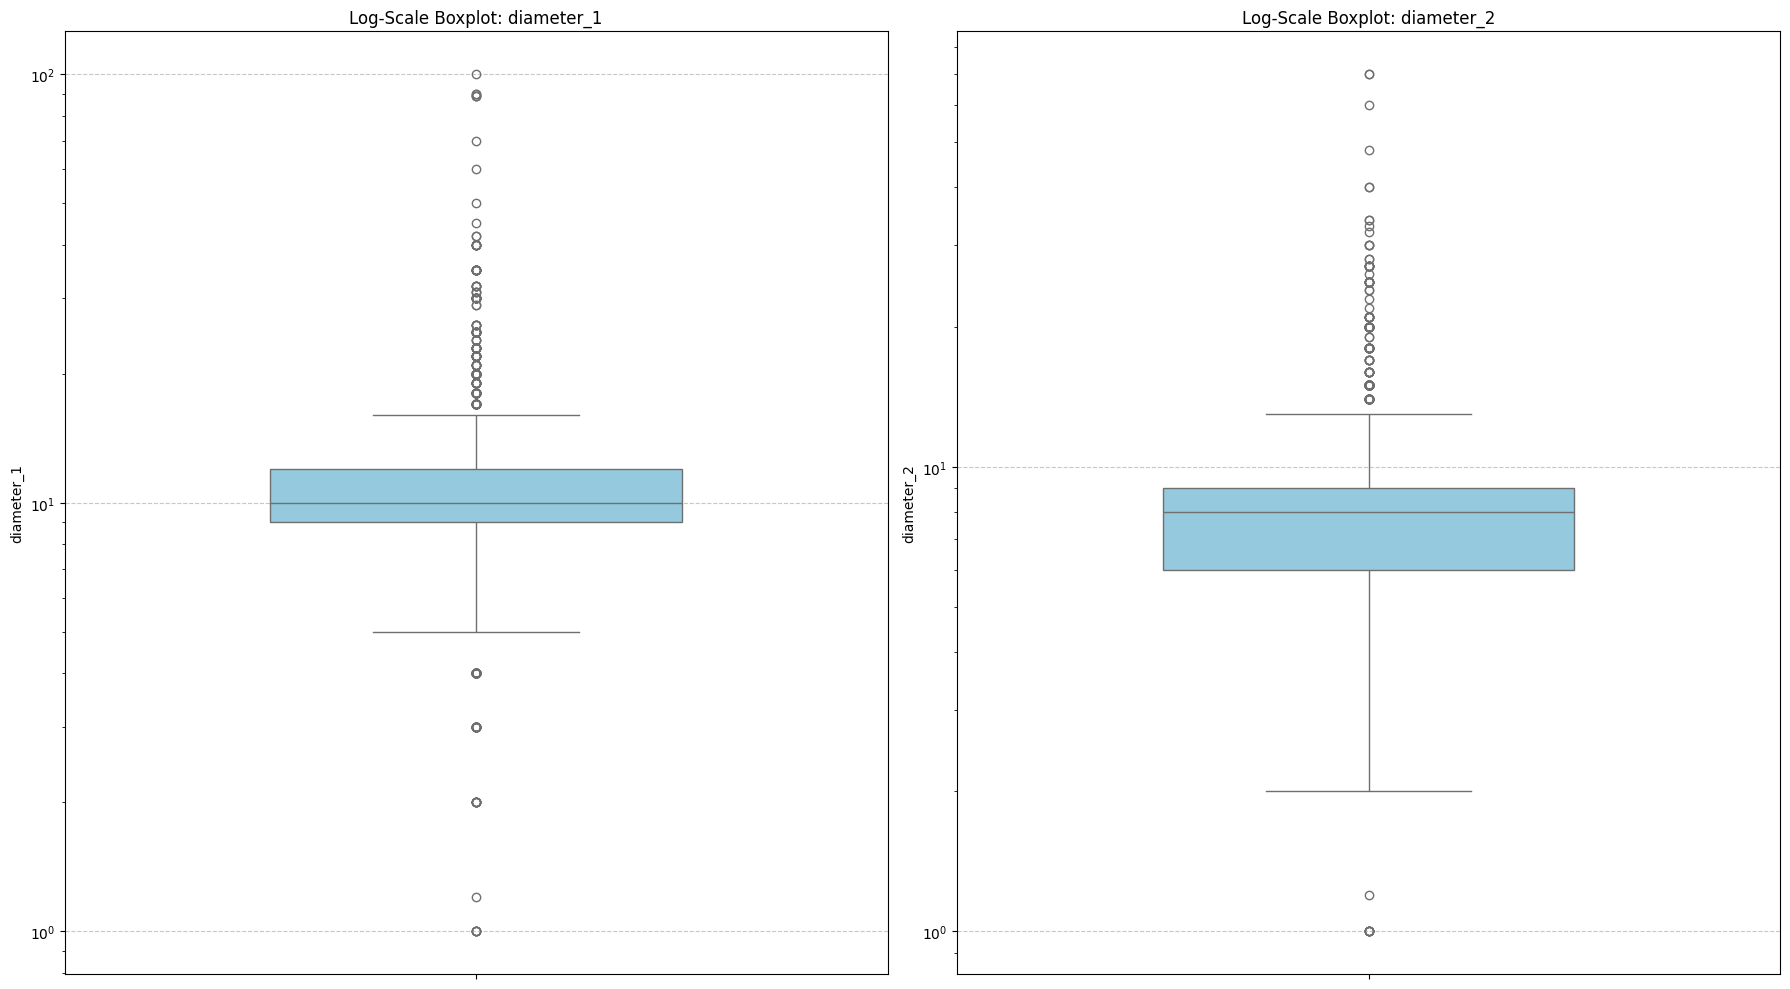

In [193]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 10))

for i, col in enumerate(num_cols):
    sns.boxplot(y=clean_pad_dataset[col], ax=axes[i], color='skyblue', width=0.5)
    
    axes[i].set_yscale('log')
    axes[i].set_title(f'Log-Scale Boxplot: {col}')
    
    # Add a grid to make the scale easier to read
    axes[i].grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()